# Liesel-GAM Demo Notebook

## Setup and Imports

In [25]:
import jax
import jax.numpy as jnp
import liesel.goose as gs
import liesel.model as lsl
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel_gam as gam

In [26]:
# import data from R
from ryp import r, to_py

r("library(mgcv)")
r("data(columb)")
r("data(columb.polys)")

columb = to_py("columb", format="pandas").reset_index()
polys = to_py("columb.polys", format="numpy")

In [27]:
columb.head()

,index,area,home.value,income,crime,open.space,district,x,y
0,0,0.309441,80.467003,19.531,15.725980,2.850747,0,8.827218,14.369076
1,1,0.259329,44.567001,21.232,18.801754,5.296720,1,8.332658,14.031624
2,2,0.192468,26.350000,15.956,30.626781,4.534649,2,9.012265,13.819719
3,3,0.083841,33.200001,4.477,32.387760,0.394427,3,8.460801,13.716962
4,4,0.488888,23.225000,11.252,50.731510,0.405664,4,9.007982,13.296366


## Model Definition

### Setup response model

In [ ]:
df = columb
tb = gam.TermBuilder.from_df(df)

loc = gam.AdditivePredictor("$\\mu$")
scale = gam.AdditivePredictor("$\\sigma$", inv_link=jnp.exp)


y = lsl.Var.new_obs(
    value=df.crime.to_numpy(),
    distribution=lsl.Dist(tfd.Normal, loc=loc, scale=scale),
    name="y",
)


smooth = tb.ps("area")

loc += smooth

ri = tb.ri("district", scale=1.0)
ri_pos = lsl.Var.new_calc(jax.nn.softplus, ri, name="sp(" + ri.name + ")")

scaled_smooth = lsl.Var.new_calc(
    lambda smooth, ri: smooth * ri, smooth=smooth, ri=ri_pos, name="rs(area | district)"
)

loc += scaled_smooth

loc += tb.ri("district")

### Build and plot model

liesel.model.model - INFO - Converted dtype of Value(name="y_value").value


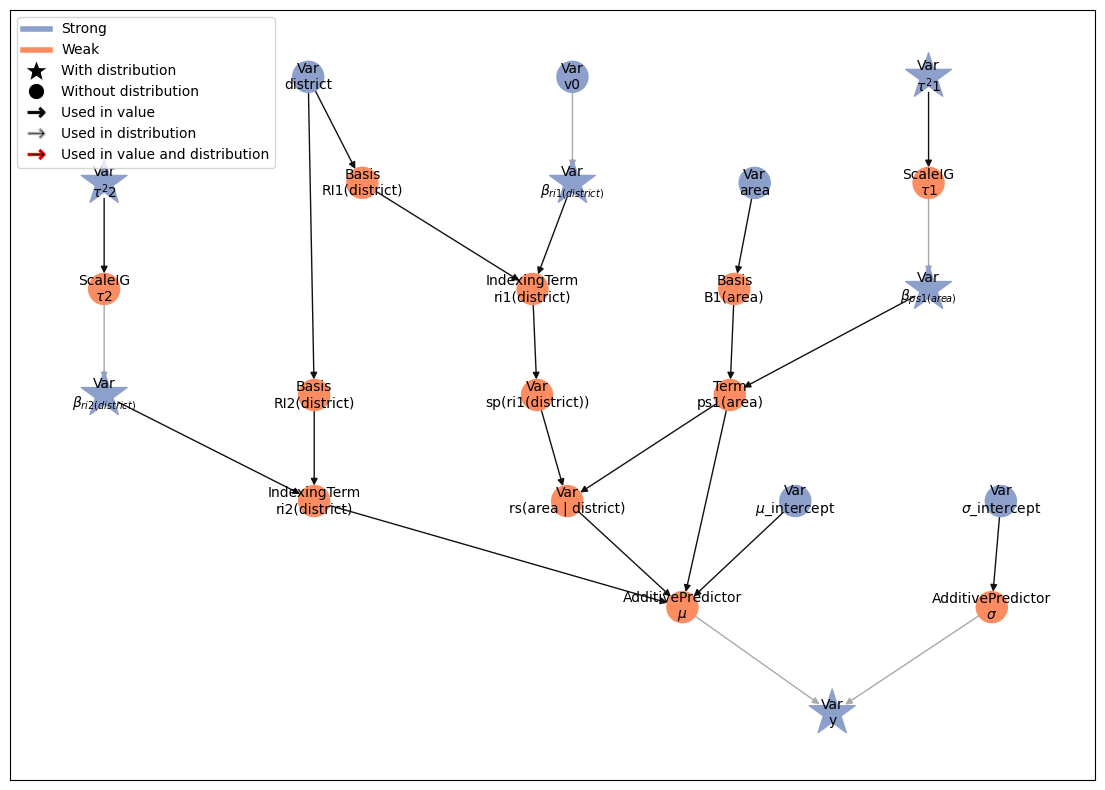

In [29]:
model = lsl.Model([y])
model.plot_vars()

## Run MCMC

Since we used the `inference` arguments to specify MCMC kernels for all parameters above,
we can quickly set up the MCMC engine with `gs.LieselMCMC` (new in v0.4.0).

In [30]:
eb = gs.LieselMCMC(model).get_engine_builder(
    seed=1, num_chains=4
)  # New in liesel v0.4.0

eb.set_epochs(
    gs.stan_epochs(
        warmup_duration=1000,
        posterior_duration=10000,
        init_duration=400,
        term_duration=400,
        thinning_posterior=10,
    )
)
engine = eb.build()
engine.sample_all_epochs()
results = engine.get_results()

liesel.goose.builder - WARNING - No jitter functions provided for position keys '$\\sigma$_intercept', '$\\mu$_intercept', '$\\beta_{ri2(district)}$', '$\\tau^2$2', '$\\beta_{ri1(district)}$', '$\\beta_{ps1(area)}$', '$\\tau^2$1'. The initial values for these keys won't be jittered
liesel.goose.engine - INFO - Initializing kernels...
liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 400 transitions, 25 jitted together
100%|████████████████████████████████████████| 16/16 [00:05<00:00,  3.04chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_04: 7, 7, 6, 7 / 400 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 820.96chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 0, 0, 0, 1 / 25 transitions
liesel.goose.engine - INFO - Finished epoch


### MCMC summary

In [31]:
summary = gs.Summary(results)
summary

Parameter summary:

                                  kernel       mean        sd     q_0.05  \
parameter               index                                              
$\beta_{ps1(area)}$     (0,)   kernel_05   0.005409  0.255536  -0.375253   
                        (1,)   kernel_05  -0.005705  0.253130  -0.395960   
                        (2,)   kernel_05  -0.006652  0.255458  -0.417665   
                        (3,)   kernel_05   0.002790  0.250636  -0.383256   
                        (4,)   kernel_05  -0.002725  0.250425  -0.400140   
...                                  ...        ...       ...        ...   
$\beta_{ri2(district)}$ (48,)  kernel_02  -0.002211  0.118546  -0.186284   
$\mu$_intercept         ()     kernel_01  35.102287  2.034743  31.744910   
$\sigma$_intercept      ()     kernel_00   2.620797  0.113663   2.438231   
$\tau^2$1               ()     kernel_06   0.065119  0.086339   0.004747   
$\tau^2$2               ()     kernel_03   0.014095  0.022021   0.001666   

                                   q_0.5     q_0.95  sample_size     ess_bulk  \
parameter               index                                                   
$\beta_{ps1(area)}$     (0,)   -0.000815   0.405638         4000  3515.034097   
                        (1,)   -0.003200   0.383638         4000  3564.324927   
                        (2,)   -0.001025   0.378193         4000  3484.506759   
                        (3,)    0.000948   0.405010         4000  3793.497808   
                        (4,)   -0.003140   0.389251         4000  3529.782183   
...                                  ...        ...          ...          ...   
$\beta_{ri2(district)}$ (48,)  -0.000350   0.172593         4000  2962.726266   
$\mu$_intercept         ()     35.097136  38.448277         4000  4022.822027   
$\sigma$_intercept      ()      2.618388   2.811056         4000  2506.651526   
$\tau^2$1               ()      0.036808   0.220009         4000   596.349621   
$\tau^2$2               ()      0.006928   0.050478         4000   192.182651   

                                  ess_tail      rhat  
parameter               index                         
$\beta_{ps1(area)}$     (0,)   2330.950895  1.003805  
                        (1,)   3086.564988  1.002027  
                        (2,)   2936.159929  1.003379  
                        (3,)   2389.123202  1.004454  
                        (4,)   2673.935978  1.002069  
...                                    ...       ...  
$\beta_{ri2(district)}$ (48,)  1589.914401  1.002742  
$\mu$_intercept         ()     3797.493723  1.000125  
$\sigma$_intercept      ()     3330.055570  1.001084  
$\tau^2$1               ()      845.886732  1.010184  
$\tau^2$2               ()      370.804027  1.019268  

[121 rows x 10 columns]

Error summary:

                                                   count relative
kernel    error_code error_msg           phase                   
kernel_00 90         nan acceptance prob warmup        1  0.00025
                                         posterior     0      0.0
kernel_04 90         nan acceptance prob warmup       27  0.00675
                                         posterior     0      0.0

## Plots

In [32]:
samples = results.get_posterior_samples()

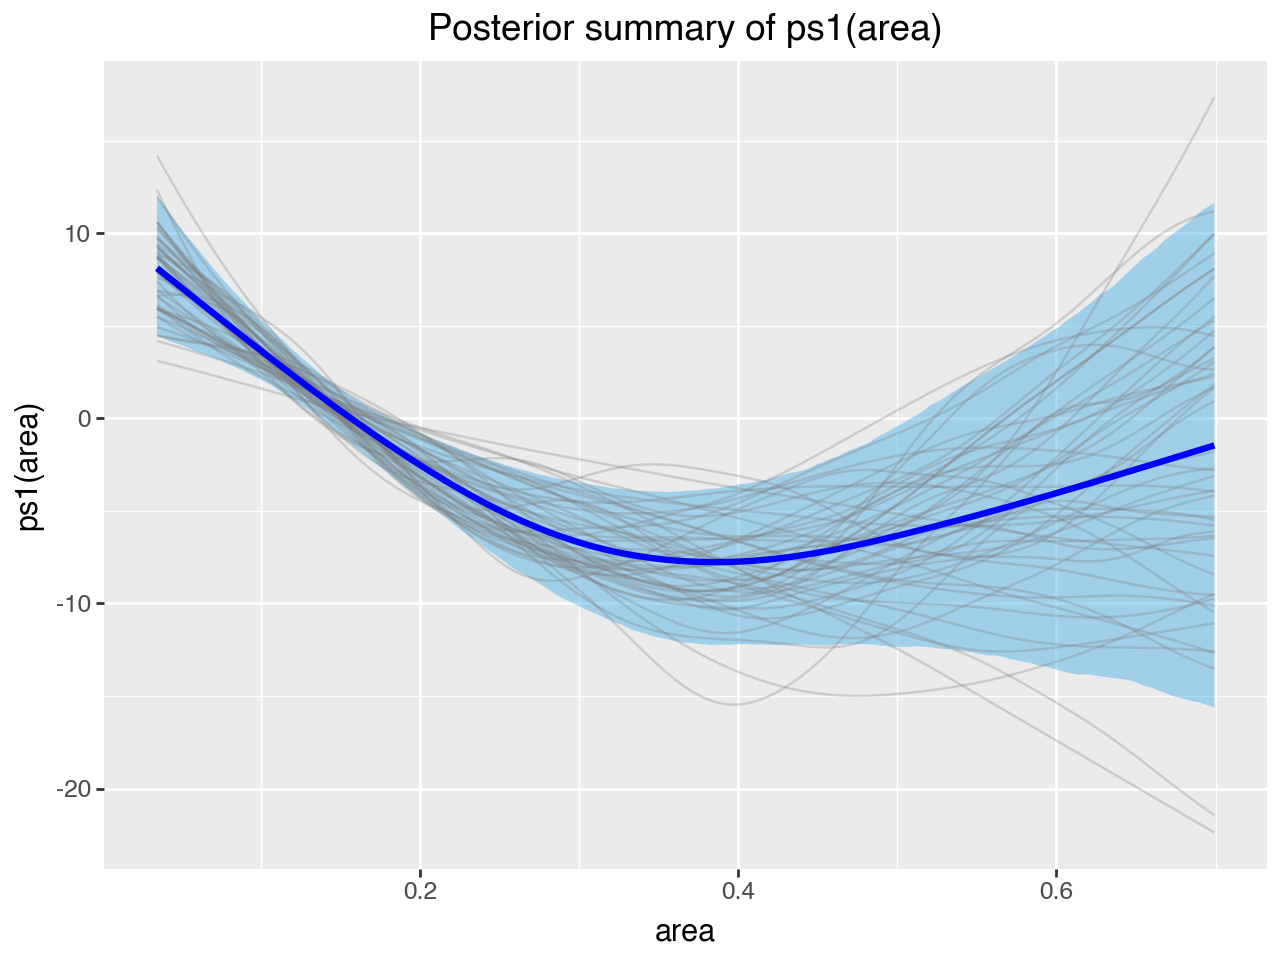

In [33]:
gam.plot_1d_smooth(term=model.vars[smooth.name], samples=samples)

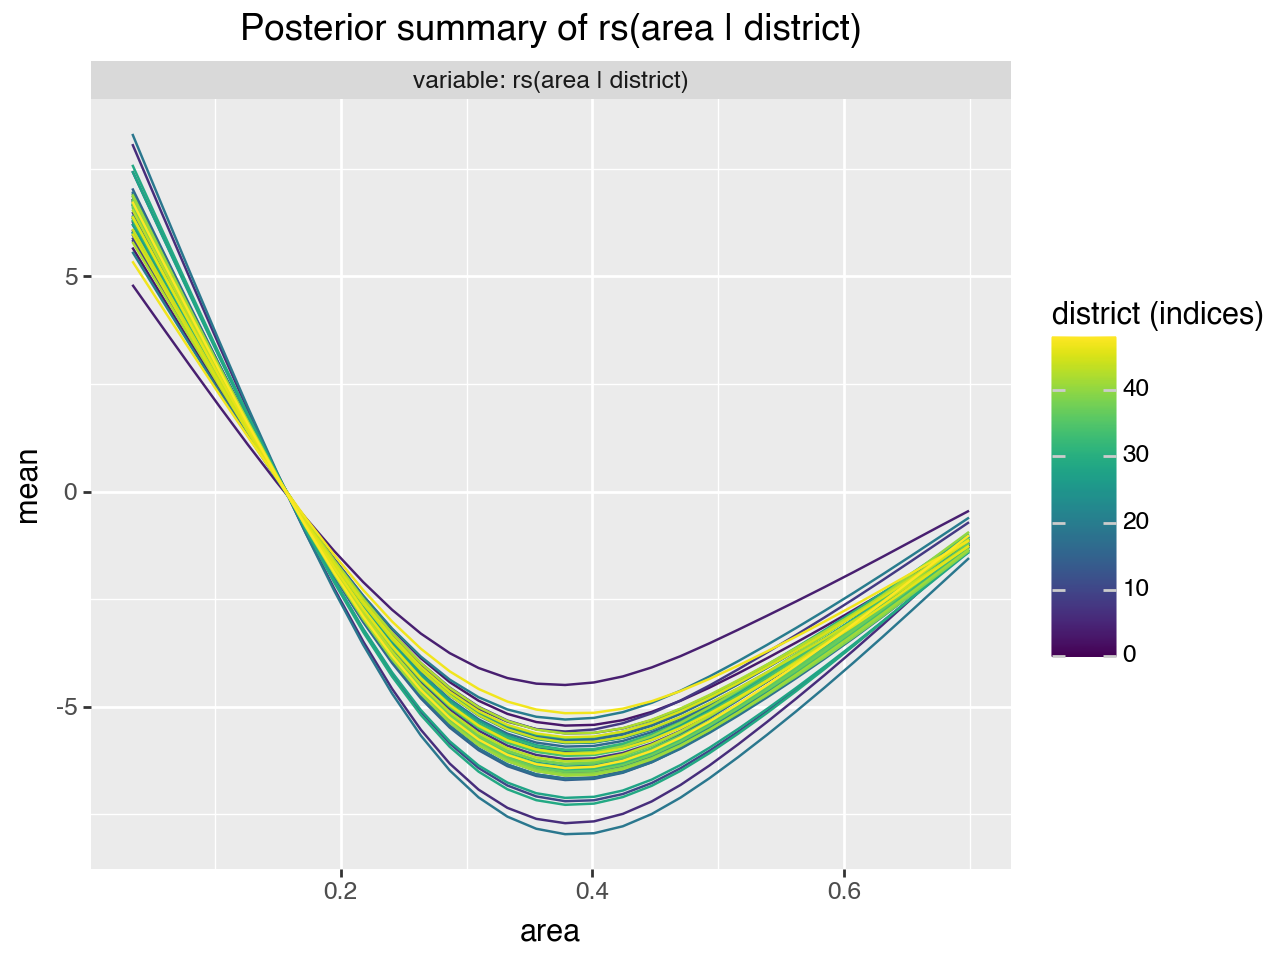

In [34]:
gam.plot_1d_smooth_clustered(
    term=model.vars["rs(area | district)"],
    x=model.vars["area"],
    cluster=model.vars["district"],
    samples=samples,
    ngrid=30,
)

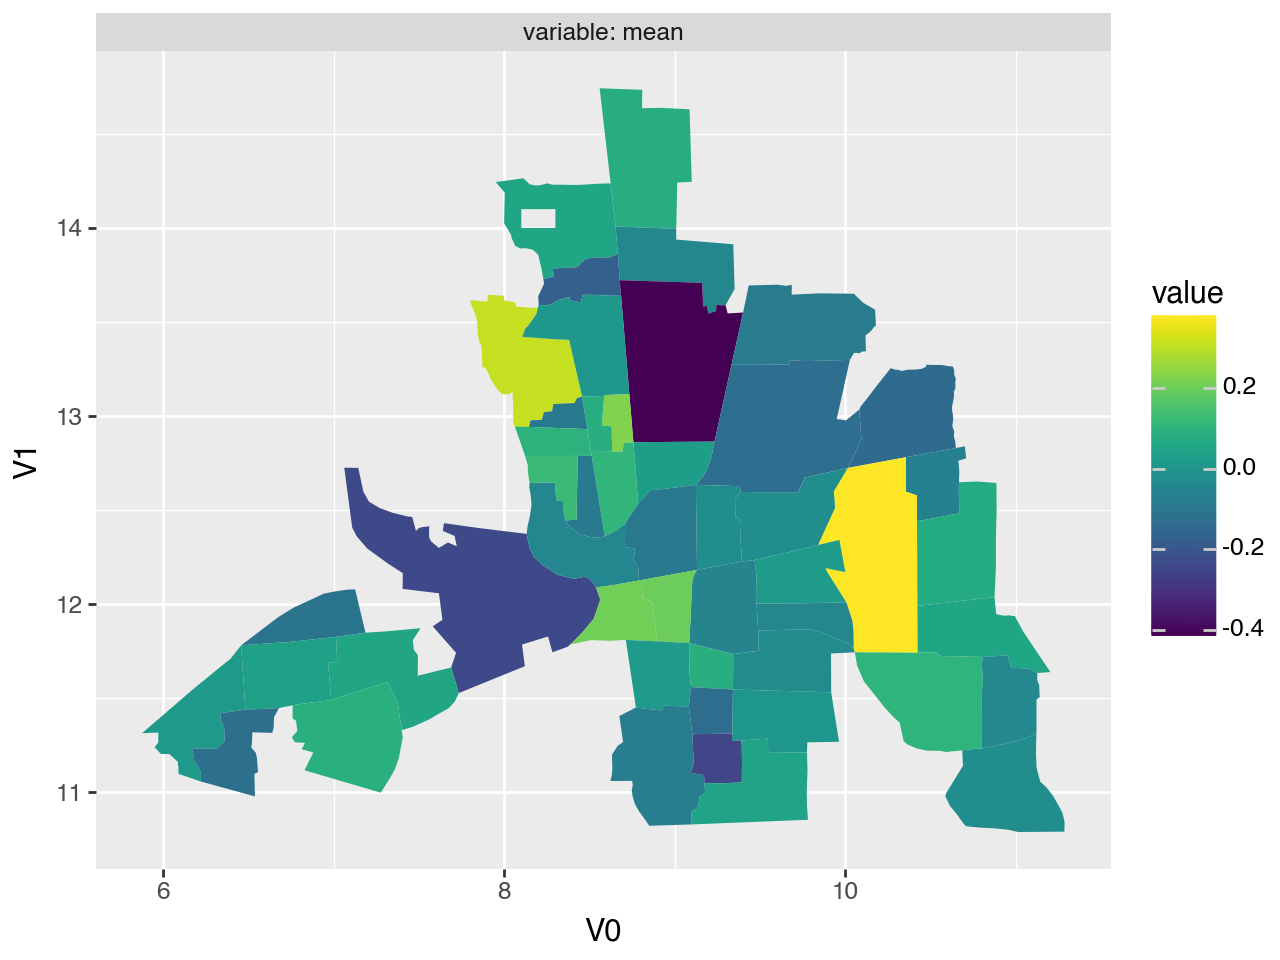

In [35]:
gam.plot_regions(term=model.vars["ri1(district)"], samples=samples, polys=polys)

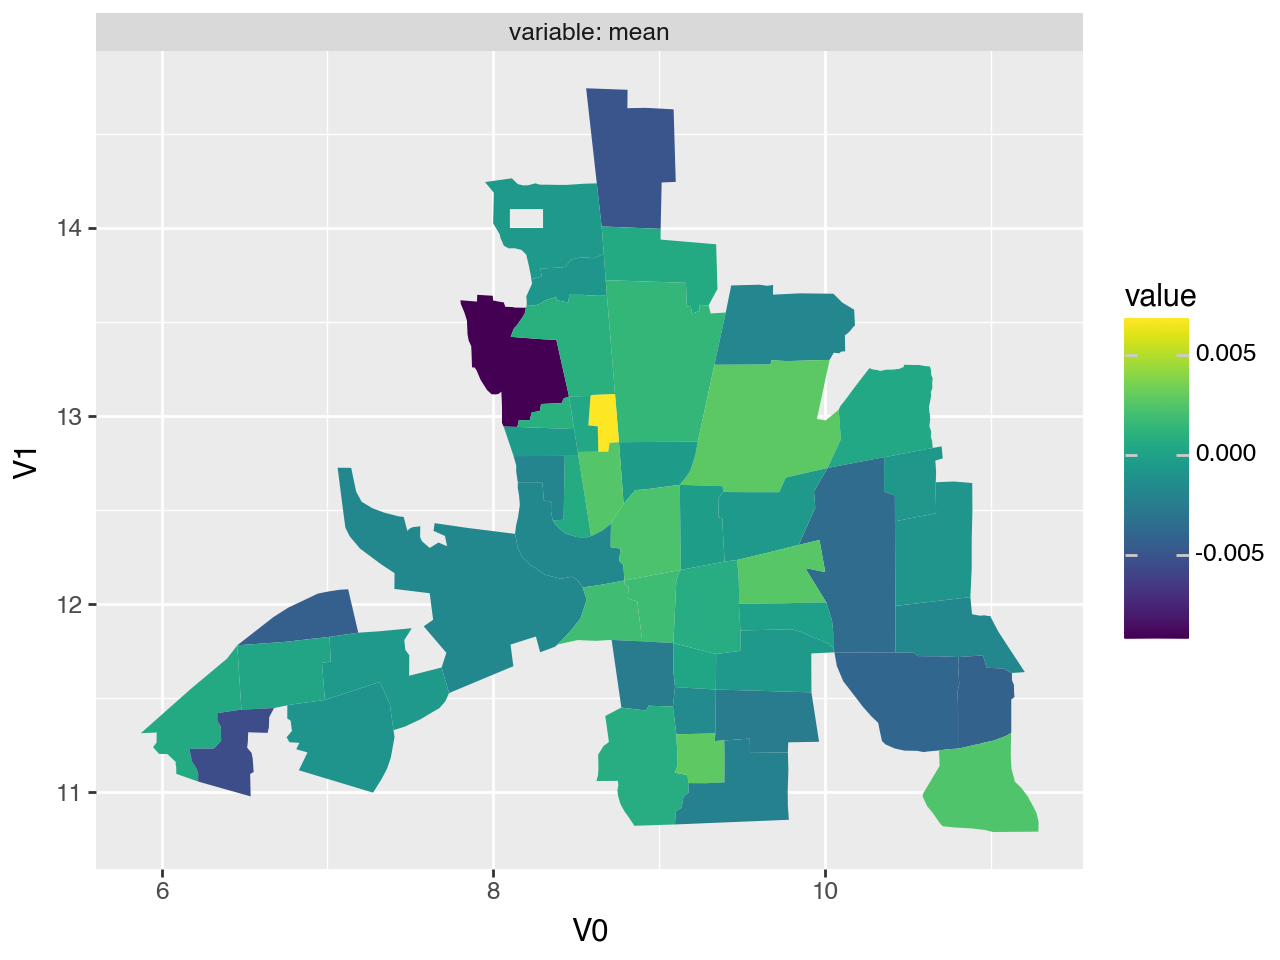

In [36]:
gam.plot_regions(term=model.vars["ri2(district)"], samples=samples, polys=polys)